In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
df = pd.read_csv("/content/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df["Average"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["Result"] = df["Average"].apply(lambda x: 1 if x >= 40 else 0)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average,Result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [4]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

In [5]:
X = df.drop(["Average", "Result"], axis=1)

y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [7]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [8]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [9]:
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():

    print("\n", name)

    print("Accuracy :", accuracy_score(y_test, pred))

    print("Precision:", precision_score(y_test, pred))

    print("Recall   :", recall_score(y_test, pred))

    print("F1 Score :", f1_score(y_test, pred))


 Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

 Decision Tree
Accuracy : 0.995
Precision: 0.9947643979057592
Recall   : 1.0
F1 Score : 0.9973753280839895

 Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [10]:
print("Logistic Regression CV Accuracy:",
      cross_val_score(lr, X, y, cv=5).mean())

print("Decision Tree CV Accuracy:",
      cross_val_score(dt, X, y, cv=5).mean())

print("Random Forest CV Accuracy:",
      cross_val_score(rf, X, y, cv=5).mean())

Logistic Regression CV Accuracy: 0.998
Decision Tree CV Accuracy: 0.9890000000000001
Random Forest CV Accuracy: 0.9960000000000001


In [11]:
param_dt = {
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10],
    "criterion":["gini","entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)

best_dt = grid_dt.best_estimator_

print("Accuracy:",
      accuracy_score(y_test, best_dt.predict(X_test)))

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Accuracy: 0.99


In [12]:
param_rf = {
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10],
    "min_samples_split":[2,5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

print("Accuracy:",
      accuracy_score(y_test, best_rf.predict(X_test)))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 1.0


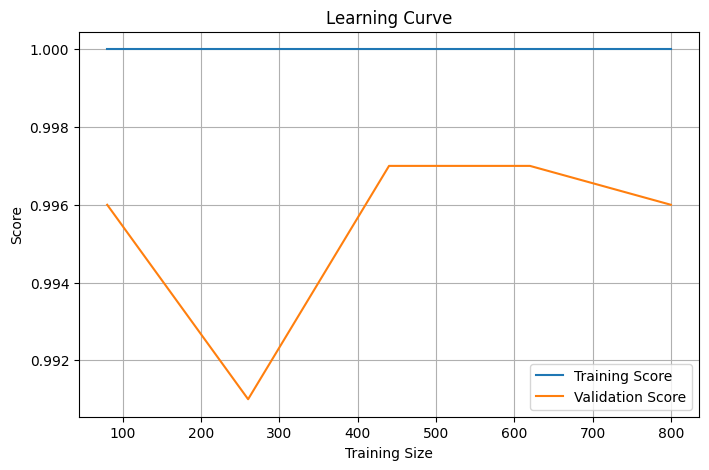

In [13]:
train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X,
    y,
    cv=5
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

In [14]:
print(classification_report(y_test, best_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00       190

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

